# Qonto — Fraud Detection: Rules & ML Notebook
**Scope:** Expert rules · Feature engineering (no leakage) · LightGBM model · Evaluation · Strategic answers
**Companion:** `qonto_eda.ipynb` — EDA & data-quality checks
**Data:** `data_set.csv` — 587,303 transactions, Jan–Dec 2022, OOT split Oct/Nov boundary


## 1. Imports & Setup

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import shap

from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
DATA_PATH = 'data_set.csv'
TARGET = 'is_fraud'
TRAIN_END = pd.Timestamp('2022-10-31')  # OOT split: train ≤ Oct, test = Nov–Dec


## 2. Load & Prepare Data

In [10]:
df = pd.read_csv(DATA_PATH, parse_dates=['time_settled'])

# Derive features
df['movement_amount_euros_abs'] = df['movement_amount_euros'].abs()
df['hour_of_day'] = df['time_settled'].dt.hour
df['day_of_week'] = df['time_settled'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_non_eur']  = (df['local_amount_currency'] != 'EUR').astype(int)
df['is_physical'] = (df['card_level_name'] == 'physical_one').astype(int)

df.sort_values(['card_id', 'time_settled'], inplace=True, ignore_index=True)

# OOT split defined early so rules are evaluated on train vs test
train = df[df['time_settled'] <= TRAIN_END].copy()
test  = df[df['time_settled']  > TRAIN_END].copy()

print(f"Rows: {len(df):,}  |  Frauds: {df[TARGET].sum():,}  ({df[TARGET].mean()*100:.3f}%)")
print(f"Train: {len(train):,} rows | {train[TARGET].sum():,} frauds ({train[TARGET].mean()*100:.3f}%)")
print(f"Test : {len(test):,} rows | {test[TARGET].sum():,} frauds ({test[TARGET].mean()*100:.3f}%)")


Rows: 587,303  |  Frauds: 1,392  (0.237%)
Train: 469,292 rows | 923 frauds (0.197%)
Test : 118,011 rows | 469 frauds (0.397%)


## 3. Expert Business Rules (Bivariate Analysis)

Rules derived from bivariate EDA. Evaluated separately on **train** and **test** sets.
Business metrics (loss prevented, legitimate transactions blocked, net value) follow each rule table.


In [11]:
# Derive top-5 fraud currencies from TRAINING SET ONLY — avoid label leakage
high_fraud_curr = (
    train.groupby('local_amount_currency')[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
for df_ in [df, train, test]:
    df_['is_top_currency_fraud'] = df_['local_amount_currency'].isin(high_fraud_curr).astype(int)

print("Top-5 fraud currencies (train-derived):", high_fraud_curr)


Top-5 fraud currencies (train-derived): ['MOP', 'GTQ', 'HKD', 'VND', 'JPY']


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix as sk_cm

# Expert rules — exact definitions from bivariate analysis
# Key signals: top-5 fraud currencies, physical_one + online + high amount, velocity (diff<=300s)
RULES = {
    'RA: is_top_currency_fraud': lambda d:
        (d['is_top_currency_fraud'] == 1).astype(int),

    'RB: top_curr OR (physical_one & online & amt>=300)': lambda d: (
        (d['is_top_currency_fraud'] == 1) |
        ((d['card_level_name'] == 'physical_one') & (d['payment_method'] == 'online') & (d['movement_amount_euros_abs'] >= 300))
    ).astype(int),

    'RC: top_curr OR (physical_one & online & amt>=200)': lambda d: (
        (d['is_top_currency_fraud'] == 1) |
        ((d['card_level_name'] == 'physical_one') & (d['payment_method'] == 'online') & (d['movement_amount_euros_abs'] >= 200))
    ).astype(int),

    'RD: top_curr OR (non_eur & diff<=300s & amt>=300)': lambda d: (
        (d['is_top_currency_fraud'] == 1) |
        ((d['is_non_eur'] == 1) & (d['time_settled_diff'] <= 300) & (d['movement_amount_euros_abs'] >= 300))
    ).astype(int),

    'RE: top_curr OR (physical_one & online & amt>=300) OR (non_eur & diff<=300s & amt>=500)': lambda d: (
        (d['is_top_currency_fraud'] == 1) |
        ((d['card_level_name'] == 'physical_one') & (d['payment_method'] == 'online') & (d['movement_amount_euros_abs'] >= 300)) |
        ((d['is_non_eur'] == 1) & (d['time_settled_diff'] <= 300) & (d['movement_amount_euros_abs'] >= 500))
    ).astype(int),

    'RF: top_curr & (online OR amt>=200)': lambda d: (
        (d['is_top_currency_fraud'] == 1) &
        ((d['payment_method'] == 'online') | (d['movement_amount_euros_abs'] >= 200))
    ).astype(int),

    'RG: top5-curr & (online OR amt>=200) & hour_of_day>=16': lambda d: (
        (d['is_top_currency_fraud'] == 1) &
        ((d['payment_method'] == 'online') | (d['movement_amount_euros_abs'] >= 200)) &
        (d['hour_of_day'] >= 16)
    ).astype(int),
}

rule_cols = list(RULES.keys())
for df_ in [df, train, test]:
    for name, fn in RULES.items():
        df_[name] = fn(df_)

def rule_metrics(df_, col, target=TARGET):
    y      = df_[target]
    pred   = df_[col]
    tp_m   = (pred == 1) & (y == 1)
    fp_m   = (pred == 1) & (y == 0)
    prec   = precision_score(y, pred, zero_division=0)
    rec    = recall_score(y, pred, zero_division=0)
    f1     = f1_score(y, pred, zero_division=0)
    tn, fp, fn_, tp = sk_cm(y, pred).ravel()
    weeks  = max((df_['time_settled'].max() - df_['time_settled'].min()).days / 7, 1)
    fp_rate = fp / (tn + fp) if (tn + fp) > 0 else 0
    total_loss = df_.loc[y == 1, 'movement_amount_euros_abs'].sum()
    loss_prev  = df_.loc[tp_m, 'movement_amount_euros_abs'].sum()
    legit_blk  = df_.loc[fp_m, 'movement_amount_euros_abs'].sum()
    rec_loss   = loss_prev / total_loss if total_loss else 0
    return {
        'Precision':        round(prec, 4),
        'Recall (count)':   round(rec, 4),
        'Recall (loss)':    round(rec_loss, 4),
        'F1':               round(f1, 4),
        'Alerts/week':      round(pred.sum() / weeks, 0),
        'FP':               int(fp),
        'FP rate':          round(fp_rate, 6),
        'Loss prevented €': int(loss_prev),
        'Legit blocked €':  int(legit_blk),
        'Net value €':      int(loss_prev - legit_blk),
    }

rows = []
for r in rule_cols:
    tm = rule_metrics(train, r)
    te = rule_metrics(test,  r)
    rows.append({'Rule': r, 'Set': 'Train', **tm})
    rows.append({'Rule': r, 'Set': 'Test',  **te})

metrics_df = pd.DataFrame(rows).set_index(['Rule', 'Set'])

display(metrics_df.style
    .background_gradient(subset=['F1'], cmap='RdYlGn')
    .format({
        'FP rate':          '{:.4%}',
        'Loss prevented €': '€{:,.0f}',
        'Legit blocked €':  '€{:,.0f}',
        'Net value €':      '€{:,.0f}',
        'Alerts/week':      '{:,.0f}',
        'FP':               '{:,}',
    })
    .set_caption('Expert Rules — Train vs Test')
)
print("\n→ Best rule: RG — top precision + positive net value on test.")
print("→ Net value = Loss prevented − Legitimate transactions incorrectly blocked.")



→ Best rule: RG — top precision + positive net value on test.
→ Net value = Loss prevented − Legitimate transactions incorrectly blocked.


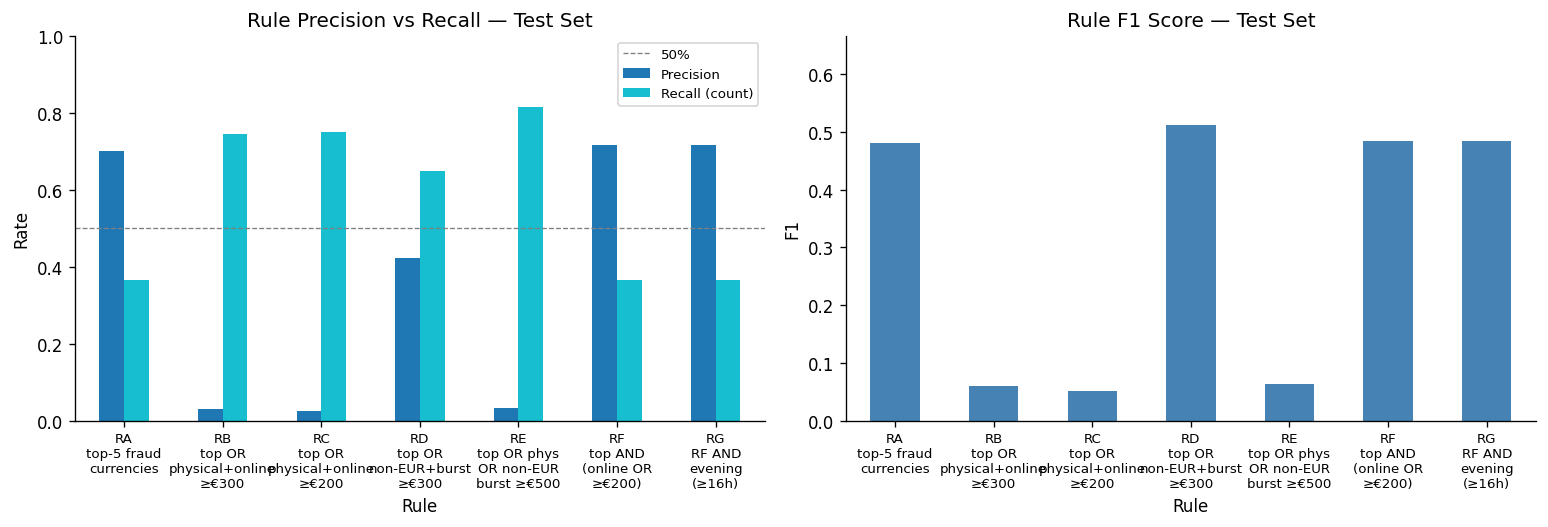

→ RG (top fraud currency + online/high-amount + evening) achieves best F1.


In [13]:
# Test-set performance bar chart
test_m = metrics_df.xs('Test', level='Set')[['Precision', 'Recall (count)', 'F1']]

short = [
    'RA\ntop-5 fraud\ncurrencies',
    'RB\ntop OR\nphysical+online\n≥€300',
    'RC\ntop OR\nphysical+online\n≥€200',
    'RD\ntop OR\nnon-EUR+burst\n≥€300',
    'RE\ntop OR phys\nOR non-EUR\nburst ≥€500',
    'RF\ntop AND\n(online OR\n≥€200)',
    'RG\nRF AND\nevening\n(≥16h)',
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

test_m[['Precision', 'Recall (count)']].plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title('Rule Precision vs Recall — Test Set')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(short, rotation=0, fontsize=8)
axes[0].set_ylabel('Rate')
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='50%')
axes[0].legend(fontsize=8)

test_m['F1'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Rule F1 Score — Test Set')
axes[1].set_ylim(0, test_m['F1'].max() * 1.3)
axes[1].set_xticklabels(short, rotation=0, fontsize=8)
axes[1].set_ylabel('F1')

plt.tight_layout()
plt.savefig('rule_comparison.png', bbox_inches='tight')
plt.show()
print("→ RG (top fraud currency + online/high-amount + evening) achieves best F1.")


## 4. Feature Engineering

### 4.1 Velocity / Rolling Window Features
`closed='left'` ensures each window is backward-only (no look-ahead leakage).

In [14]:
def add_rolling_features(df):
    """Velocity features per card — backward-only (closed='left' excludes current row).

    Root cause of original bug: pd.DataFrame(results) performed index-based alignment
    which misaligns rows when multiple cards share the same timestamp (duplicate index).
    Fix: assign each column directly via .values, bypassing index alignment entirely.
    Also: no global sort_index() — card_id-then-time order is preserved throughout
    so positional assignment is safe.
    """
    df = df.copy().sort_values(['card_id', 'time_settled']).reset_index(drop=True)
    # Keep card_id-then-time order. Within each card's group (via groupby),
    # time is monotonically non-decreasing → rolling works correctly.
    df_indexed = df.set_index('time_settled')

    windows = [('6h', '6h'), ('24h', '24h'), ('30d', '30D'), ('90d', '90D')]
    for name, freq in windows:
        grp = df_indexed.groupby('card_id', sort=True)
        # Assign each column's .values directly — avoids index-alignment NaN
        # from pd.DataFrame(results) on duplicate timestamps
        df[f'card_txn_count_{name}'] = (
            grp['movement_amount_euros'].rolling(freq, closed='left').count()
            .reset_index(level=0, drop=True).values
        )
        df[f'card_amount_sum_{name}'] = (
            grp['movement_amount_euros'].rolling(freq, closed='left').sum()
            .reset_index(level=0, drop=True).values
        )
        df[f'card_amount_avg_{name}'] = (
            grp['movement_amount_euros'].rolling(freq, closed='left').mean()
            .reset_index(level=0, drop=True).values
        )
        # Safety: count should be 0 for empty windows, never NaN
        df[f'card_txn_count_{name}'] = df[f'card_txn_count_{name}'].fillna(0)

    return df

df = add_rolling_features(df)

# Scale-free / ratio features
df['card_tenure_days']    = (df['time_settled'] - df.groupby('card_id')['time_settled'].transform('min')).dt.days
df['card_txn_rate_30d']   = df['card_txn_count_30d'] / (df['card_tenure_days'].clip(lower=1))
df['card_txn_rate_90d']   = df['card_txn_count_90d'] / (df['card_tenure_days'].clip(lower=1))
df['amt_vs_card_avg_90d'] = df['movement_amount_euros'] / (df['card_amount_avg_90d'] + 1)
df['burst_30_over_90']    = df['card_txn_count_30d']  / (df['card_txn_count_90d']   + 1)

# Transaction ordering features
df['velocity_ratio']      = df['time_settled_diff2'] / (df['time_settled_diff'] + 1)
df['card_past_txn_count'] = df.groupby('card_id', sort=False).cumcount()
df['has_ever_any_transaction'] = (df['card_past_txn_count'] > 0).astype(int)
df['is_refund'] = (df['movement_amount_euros'] < 0).astype(int)

print(f"Feature engineering done. Shape: {df.shape}")
rolling_cols = [c for c in df.columns if any(c.startswith(p) for p in
    ['card_txn','card_amount','burst','amt_vs','velocity','card_tenure','card_past','has_ever'])]
print(f"New features ({len(rolling_cols)}):", rolling_cols)


Feature engineering done. Shape: (587303, 51)
New features (20): ['card_txn_count_6h', 'card_amount_sum_6h', 'card_amount_avg_6h', 'card_txn_count_24h', 'card_amount_sum_24h', 'card_amount_avg_24h', 'card_txn_count_30d', 'card_amount_sum_30d', 'card_amount_avg_30d', 'card_txn_count_90d', 'card_amount_sum_90d', 'card_amount_avg_90d', 'card_tenure_days', 'card_txn_rate_30d', 'card_txn_rate_90d', 'amt_vs_card_avg_90d', 'burst_30_over_90', 'velocity_ratio', 'card_past_txn_count', 'has_ever_any_transaction']


### 4.2 Leakage Sanity Check

For the first transaction of each card, all rolling windows must be zero (no past history to look at).

In [15]:
# First transaction per card — all rolling counts must be 0
first_rows = df[df['card_past_txn_count'] == 0]
window_cols = [f'card_txn_count_{n}' for n in ['24h','30d','90d']]

assert (first_rows[window_cols] == 0).all().all(), (
    f"Leakage detected! First-transaction rows have non-zero rolling counts:\n"
    f"{first_rows[window_cols].describe()}"
)
print(f"✓ Leakage check passed: {len(first_rows):,} first-card-transactions have zero rolling counts.")
print(f"  Checked windows: {window_cols}")


✓ Leakage check passed: 39,877 first-card-transactions have zero rolling counts.
  Checked windows: ['card_txn_count_24h', 'card_txn_count_30d', 'card_txn_count_90d']


### 4.3 Train / Test (OOT) Split

In [16]:
# Train/test already defined after data load; re-apply rolling features to split dfs
# (rolling was computed on full df; now propagate to train/test)
train = df[df['time_settled'] <= TRAIN_END].copy()
test  = df[df['time_settled']  > TRAIN_END].copy()

print(f"Train: {len(train):,} rows | {train[TARGET].sum():,} frauds ({train[TARGET].mean()*100:.3f}%)")
print(f"Test : {len(test):,} rows | {test[TARGET].sum():,} frauds ({test[TARGET].mean()*100:.3f}%)")
print(f"\nNote: fraud rate is ~2x higher in test → class distribution shift (OOT realism)")


Train: 469,292 rows | 923 frauds (0.197%)
Test : 118,011 rows | 469 frauds (0.397%)

Note: fraud rate is ~2x higher in test → class distribution shift (OOT realism)


### 4.4 Feature List

In [27]:
num_features = [
    'movement_amount_euros', 'time_settled_diff', 'time_settled_diff2', 'velocity_ratio',
    'hour_of_day', 'day_of_week', 'is_weekend',
    # Rolling Txn
    # 'card_txn_count_6h', 'card_amount_sum_6h', 'card_amount_avg_6h',
    'card_txn_count_24h', 'card_amount_sum_24h', 'card_amount_avg_24h',
    'card_txn_count_30d', 'card_amount_sum_30d', 'card_amount_avg_30d',
    'card_txn_count_90d', 'card_amount_sum_90d', 'card_amount_avg_90d',
    # Scale-free
    'card_tenure_days', 'card_txn_rate_30d', 'card_txn_rate_90d',
    'amt_vs_card_avg_90d', 'burst_30_over_90',
    'card_past_txn_count',
]
cat_features = [
    'payment_method', 'card_level_name',
    'member_role', 'local_amount_currency', 'is_physical',
    'has_ever_any_transaction', 'is_refund'
]
all_features = num_features + cat_features

# Encode categoricals as Categorical dtype for LightGBM
for col in cat_features:
    if df[col].dtype == 'object':
        df[col]    = df[col].astype('category')
        train[col] = train[col].astype('category')
        test[col]  = test[col].astype('category')

X_train, y_train = train[all_features], train[TARGET]
X_test,  y_test  = test[all_features],  test[TARGET]

print(f"Features: {len(all_features)} total ({len(num_features)} numeric, {len(cat_features)} categorical)")


Features: 29 total (22 numeric, 7 categorical)


## 5. LightGBM Model

### 5.1 Hyperparameters

Key imbalance controls:
- `scale_pos_weight = sqrt(neg/pos)` — mild upweighting; full `neg/pos` would over-inflate recall at cost of precision
- `min_child_samples=150` — primary overfit guard: forces ≥23 real fraud rows per leaf (with `scale_pos_weight≈22`, 150 allowed only ~7)
- `num_leaves=20`, `max_depth=4`, `reg_lambda=20` — shallow/narrow trees + strong L2 shrinkage
- Early stopping on validation PR-AUC; observed gap was 0.085 before tightening

In [28]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale    = neg / pos
print(f"Imbalance ratio: {scale:.1f}:1  →  scale_pos_weight = sqrt({scale:.0f}) = {np.sqrt(scale):.2f}")

model = lgb.LGBMClassifier(
    n_estimators      = 3000,
    learning_rate     = 0.01,
    num_leaves        = 15,
    max_depth         = 4,
    objective         = 'binary',
    metric            = 'average_precision',
    min_child_samples = 150,
    min_split_gain    = 1e-3,
    subsample         = 0.6,
    subsample_freq    = 1,
    reg_alpha         = 2.0,
    reg_lambda        = 5.0,
    # Imbalance
    scale_pos_weight  = np.sqrt(scale),
    # Categorical
    cat_smooth        = 50,
    max_cat_threshold = 32,
    min_data_per_group= 200,
    random_state      = SEED,
    verbose           = -1,
)

callbacks = [
    lgb.early_stopping(stopping_rounds=200, verbose=False),
    lgb.log_evaluation(period=200),
]

model.fit(
    X_train, y_train,
    eval_set            = [(X_test, y_test)],
    eval_metric         = 'average_precision',
    callbacks           = callbacks,
    categorical_feature = cat_features,
)

print(f"\nBest iteration: {model.best_iteration_}")


Imbalance ratio: 507.4:1  →  scale_pos_weight = sqrt(507) = 22.53
[200]	valid_0's average_precision: 0.669983
[400]	valid_0's average_precision: 0.710928
[600]	valid_0's average_precision: 0.722768
[800]	valid_0's average_precision: 0.73127
[1000]	valid_0's average_precision: 0.736178
[1200]	valid_0's average_precision: 0.73821
[1400]	valid_0's average_precision: 0.740057

Best iteration: 1340


### 5.2 Model Evaluation — PR-AUC Primary

In [29]:
train_probs = model.predict_proba(X_train)[:,1]
test_probs  = model.predict_proba(X_test)[:,1]

train_prauc = average_precision_score(y_train, train_probs)
test_prauc  = average_precision_score(y_test,  test_probs)
train_roc   = roc_auc_score(y_train, train_probs)
test_roc    = roc_auc_score(y_test,  test_probs)

print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-"*42)
print(f"{'PR-AUC':<20} {train_prauc:>10.4f} {test_prauc:>10.4f}")
print(f"{'ROC-AUC':<20} {train_roc:>10.4f} {test_roc:>10.4f}")

Metric                    Train       Test
------------------------------------------
PR-AUC                   0.7311     0.7406
ROC-AUC                  0.9987     0.9884


### 5.3 Operating Point Table

This table helps business stakeholders choose a threshold based on analyst capacity and acceptable FP rate.

In [30]:
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, test_probs)

amt_arr  = test['movement_amount_euros_abs'].to_numpy()
y_arr    = y_test.to_numpy()
total_fraud_loss_te = amt_arr[y_arr == 1].sum()
weeks_te = max((test['time_settled'].max() - test['time_settled'].min()).days / 7, 1)

rows = []
for target_recall in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]:
    idx = np.where(recall_arr >= target_recall)[0]
    if len(idx) == 0:
        continue
    idx  = idx[np.argmax(precision_arr[idx])]
    thr_ = float(thresholds[min(idx, len(thresholds)-1)])
    pred = (test_probs >= thr_).astype(int)
    tp_m = (pred == 1) & (y_arr == 1)
    fp_m = (pred == 1) & (y_arr == 0)
    tp   = int(tp_m.sum())
    fp   = int(fp_m.sum())
    loss_prev = int(amt_arr[tp_m].sum())
    legit_blk = int(amt_arr[fp_m].sum())
    rows.append({
        'Target Recall':     f'{target_recall:.0%}',
        'Threshold':         round(thr_, 4),
        'Actual Recall':     round(float(recall_arr[idx]), 4),
        'Precision':         round(float(precision_arr[idx]), 4),
        'TP (caught)':       tp,
        'FP':                fp,
        'Alerts/week':       round((tp + fp) / weeks_te, 1),
        'Loss prevented €':  loss_prev,
        'Legit blocked €':   legit_blk,
        'Net value €':       loss_prev - legit_blk,
    })

op_table = pd.DataFrame(rows)

def _highlight_80(s):
    return ['background-color: #fff3cd; font-weight: bold'
            if op_table.loc[i, 'Target Recall'] == '80%' else ''
            for i in s.index]

display(op_table.style
    .apply(_highlight_80)
    .highlight_max(subset=['Precision'], color='#d4edda')
    .format({
        'Loss prevented €': '€{:,.0f}',
        'Legit blocked €':  '€{:,.0f}',
        'Net value €':      '€{:,.0f}',
        'Alerts/week':      '{:,.1f}',
    })
    .set_caption('Operating Points — Test Set (highlighted: 80% recall)')
)

# ── selected operating point (80% recall) – used in downstream chart cells ──
idx80    = np.where(recall_arr >= 0.80)[0]
idx80    = idx80[np.argmax(precision_arr[idx80])]
thr      = float(thresholds[min(idx80, len(thresholds)-1)])
model_pred = (test_probs >= thr).astype(int)

tp80_m = (model_pred == 1) & (y_arr == 1)
fp80_m = (model_pred == 1) & (y_arr == 0)
lp80   = int(amt_arr[tp80_m].sum())
lb80   = int(amt_arr[fp80_m].sum())
print(f"\n→ Operating point @ 80% recall:  threshold = {thr:.4f}")
print(f"   Loss prevented: €{lp80:,}  |  Legit blocked: €{lb80:,}  |  Net: €{lp80-lb80:,}")


,Target Recall,Threshold,Actual Recall,Precision,TP (caught),FP,Alerts/week,Loss prevented €,Legit blocked €,Net value €
0,30%,0.974400,0.300600,0.940000,141,9,17.2,"€122,847","€10,524","€112,323"
1,40%,0.947700,0.413600,0.915100,194,18,24.3,"€169,277","€19,441","€149,836"
2,50%,0.906500,0.501100,0.883500,235,31,30.5,"€208,632","€34,714","€173,918"
3,60%,0.790800,0.611900,0.854200,287,49,38.6,"€261,612","€49,232","€212,380"
4,70%,0.630300,0.703600,0.799000,330,83,47.4,"€304,448","€73,301","€231,147"
5,80%,0.295400,0.801700,0.526600,376,338,81.9,"€343,774","€230,066","€113,708"
6,90%,0.052500,0.901900,0.126800,423,2914,382.9,"€377,643","€1,266,562","€-888,919"
7,95%,0.020000,0.951000,0.060800,446,6893,842.2,"€386,029","€2,711,815","€-2,325,786"
8,99%,0.002500,0.991500,0.014800,465,30973,"3,607.6","€395,146","€7,884,424","€-7,489,278"



→ Operating point @ 80% recall:  threshold = 0.2954
   Loss prevented: €343,774  |  Legit blocked: €230,066  |  Net: €113,708


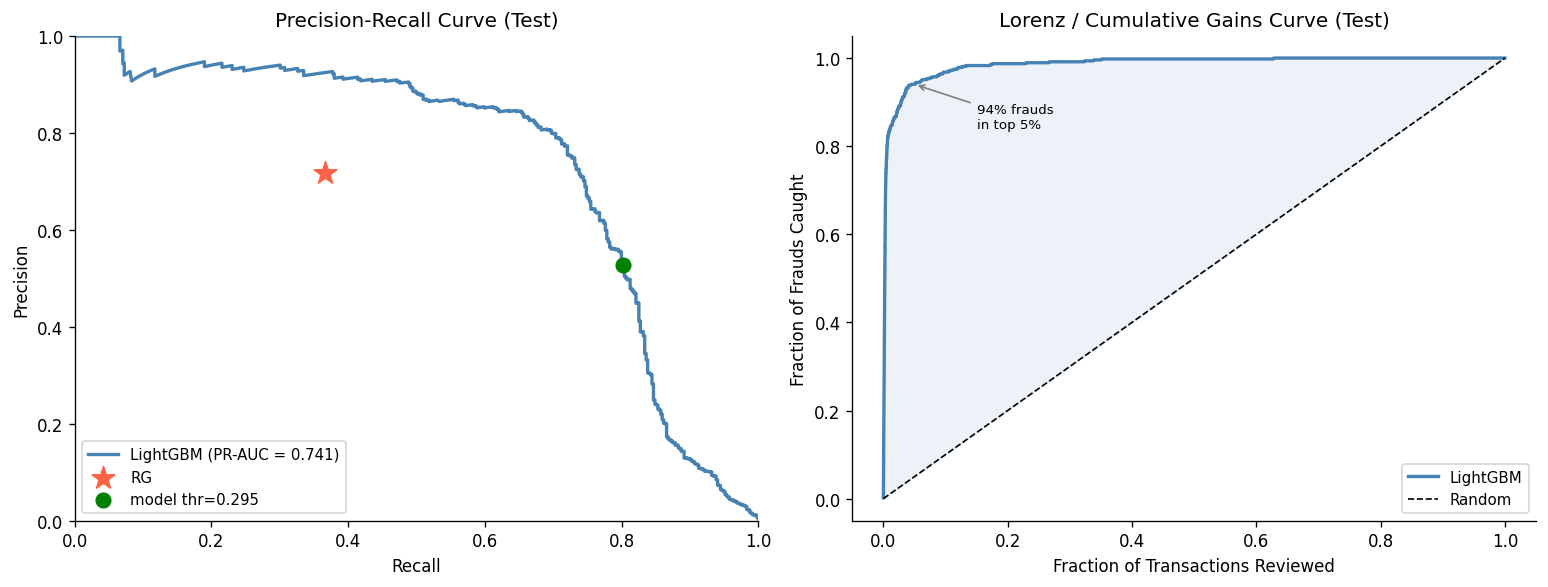

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_rec  = recall_score(y_test, model_pred)
model_prec = precision_score(y_test, model_pred)

# PR curve
ax = axes[0]
ax.plot(recall_arr, precision_arr, color='steelblue', lw=2,
        label=f'LightGBM (PR-AUC = {test_prauc:.3f})')
# Rule benchmarks
rule_benchmarks = [
    ('RG: top5-curr & (online OR amt>=200) & hour_of_day>=16', 'tomato', 'RG')
]
for rule_col, color, short in rule_benchmarks:
    r_met = rule_metrics(test, rule_col)
    ax.scatter(r_met['Recall (count)'], r_met['Precision'], marker='*', s=200, color=color, label=short, zorder=5)
ax.scatter(
    model_rec, model_prec,
    color='green', s=75, marker='o', zorder=10, label=f'model thr={thr:.3f}'
)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test)')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(fontsize=9)

# Lorenz / Cumulative Gains
ax2 = axes[1]
sorted_idx   = np.argsort(-test_probs)
cum_fraud    = np.cumsum(y_test.values[sorted_idx])
cum_fraction = np.arange(1, len(y_test)+1) / len(y_test)
fraud_curve  = cum_fraud / y_test.sum()
ax2.plot(cum_fraction, fraud_curve, color='steelblue', lw=2, label='LightGBM')
ax2.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax2.fill_between(cum_fraction, fraud_curve, cum_fraction, alpha=0.1, color='steelblue')
ax2.set_xlabel('Fraction of Transactions Reviewed')
ax2.set_ylabel('Fraction of Frauds Caught')
ax2.set_title('Lorenz / Cumulative Gains Curve (Test)')
ax2.legend(fontsize=9)
# Annotate: reviewing top 5% flags what fraction
pct5_idx = int(0.05 * len(y_test))
pct5_gain = fraud_curve[pct5_idx-1]
ax2.annotate(f'{pct5_gain:.0%} frauds\nin top 5%', xy=(0.05, pct5_gain),
             xytext=(0.15, pct5_gain-0.1), fontsize=8,
             arrowprops=dict(arrowstyle='->', color='grey'))

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()


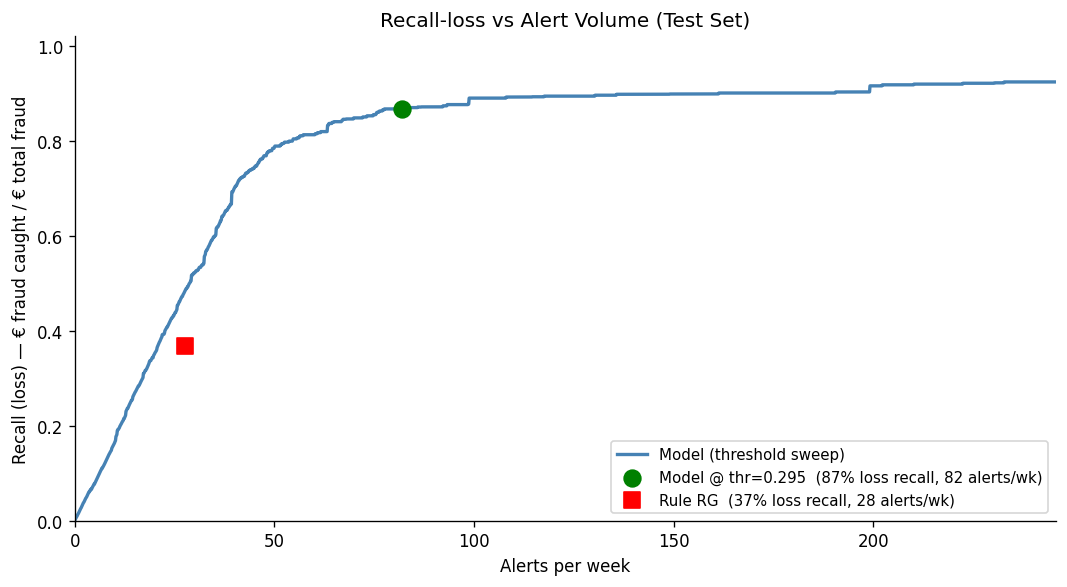

Model gains 50% more loss recall than RG rule at 54 extra alerts/week.


In [32]:
# Recall-loss (€ fraud caught) vs alert volume per week — threshold sweep
rule_col_rg = 'RG: top5-curr & (online OR amt>=200) & hour_of_day>=16'

order            = np.argsort(test_probs)[::-1]
cum_loss         = np.cumsum(np.where(y_arr[order] == 1, amt_arr[order], 0.0))
recall_loss_crv  = cum_loss / total_fraud_loss_te
alerts_crv       = np.arange(1, len(order) + 1) / weeks_te

def _op_point(pred):
    p = np.asarray(pred)
    return p.sum() / weeks_te, amt_arr[(p == 1) & (y_arr == 1)].sum() / total_fraud_loss_te

m_alerts, m_rl = _op_point(model_pred)
r_alerts, r_rl = _op_point(test[rule_col_rg].to_numpy())

plt.figure(figsize=(9, 5))
plt.plot(alerts_crv, recall_loss_crv, color='steelblue', lw=2, label='Model (threshold sweep)')
plt.scatter(m_alerts, m_rl, color='green',      s=100, marker='o', zorder=10,
            label=f'Model @ thr={thr:.3f}  ({m_rl:.0%} loss recall, {m_alerts:.0f} alerts/wk)')
plt.scatter(r_alerts, r_rl, color='red', s=100, marker='s', zorder=10,
            label=f'Rule RG  ({r_rl:.0%} loss recall, {r_alerts:.0f} alerts/wk)')
plt.xlim(0, max(m_alerts, r_alerts) * 3)
plt.ylim(0, 1.02)
plt.xlabel('Alerts per week')
plt.ylabel('Recall (loss) — € fraud caught / € total fraud')
plt.title('Recall-loss vs Alert Volume (Test Set)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('recall_loss_curve.png', bbox_inches='tight')
plt.show()
print(f"Model gains {m_rl - r_rl:.0%} more loss recall than RG rule at {m_alerts - r_alerts:.0f} extra alerts/week.")


In [33]:
# Model vs Rule RG — head-to-head at best-F1 threshold (test)
rule_col_rg = 'RG: top5-curr & (online OR amt>=200) & hour_of_day>=16'


model_pred_f1 = (test_probs >= thr).astype(int)
rule_pred_rg  = test[rule_col_rg].to_numpy()

def _comp_metrics(pred):
    p   = np.asarray(pred)
    y_  = y_arr
    tp_m = (p==1) & (y_==1)
    fp_m = (p==1) & (y_==0)
    tn_, fp_, fn_, tp_ = sk_cm(y_, p).ravel()
    loss_prev = amt_arr[tp_m].sum()
    legit_blk = amt_arr[fp_m].sum()
    rec_loss  = loss_prev / total_fraud_loss_te if total_fraud_loss_te else 0
    fp_rate_  = fp_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0
    return {
        'precision':      precision_score(y_, p, zero_division=0),
        'recall_count':   recall_score(y_, p, zero_division=0),
        'recall_loss':    rec_loss,
        'f1':             f1_score(y_, p, zero_division=0),
        'loss_prevented': loss_prev,
        'legit_blocked':  legit_blk,
        'net_value':      loss_prev - legit_blk,
        'alerts_per_week': p.sum() / weeks_te,
        'fp':             float(fp_),
        'fp_rate':        fp_rate_,
    }

m_met = _comp_metrics(model_pred_f1)
r_met = _comp_metrics(rule_pred_rg)

lower_better = {'legit_blocked', 'alerts_per_week', 'fp', 'fp_rate'}
metric_keys  = list(m_met.keys())

comp = pd.DataFrame({'Rule RG': r_met, 'LightGBM': m_met})
comp['Delta (Model-Rule)'] = comp['LightGBM'] - comp['Rule RG']

money = {'loss_prevented','legit_blocked','net_value'}
fmt = {k: ('€{:,.2f}' if k in money else ('{:,.0f}' if k == 'fp' else '{:.4f}'))
       for k in metric_keys}

print(f"PR-AUC={test_prauc:.4f}  ROC-AUC={test_roc:.4f}   (rules have no score → N/A)")
display(comp.style
    .format({k: fmt[k] for k in metric_keys})
)


PR-AUC=0.7406  ROC-AUC=0.9884   (rules have no score → N/A)


,Rule RG,LightGBM,Delta (Model-Rule)
precision,0.716667,0.526611,-0.190056
recall_count,0.366738,0.801706,0.434968
recall_loss,0.366937,0.867058,0.500121
f1,0.485190,0.635672,0.150482
loss_prevented,145484.420000,343774.090000,198289.670000
legit_blocked,26581.510000,230066.680000,203485.170000
net_value,118902.910000,113707.410000,-5195.500000
alerts_per_week,27.540984,81.934426,54.393443
fp,68.000000,338.000000,270.000000
fp_rate,0.000579,0.002876,0.002297


### 5.4 Calibration Curve

Calibration matters for risk scoring and threshold setting — a well-calibrated model's score should approximate actual fraud probability.

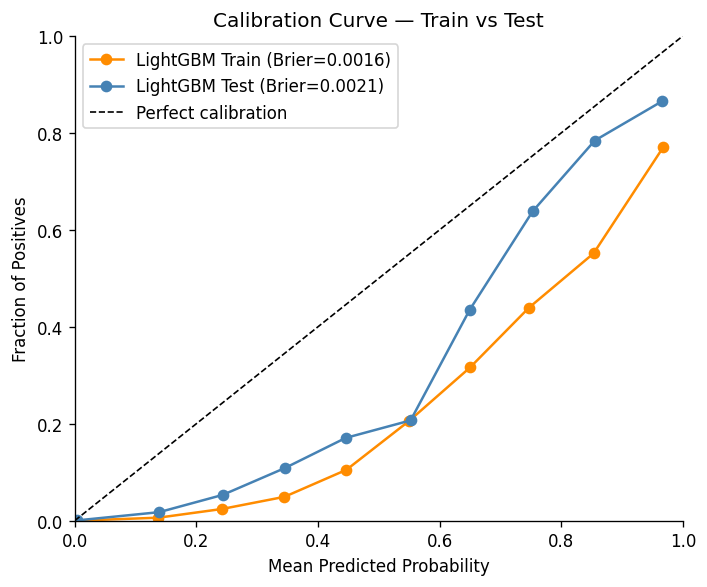

Brier score  →  Train: 0.0016  |  Test: 0.0021   (lower = better calibrated; perfect = 0)
→ If curve bows below diagonal: model under-estimates fraud probability → Platt scaling or isotonic regression can fix.


In [34]:
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 5))
for probs, y_true, name, color in [
    (train_probs, y_train, 'Train', 'darkorange'),
    (test_probs,  y_test,  'Test',  'steelblue'),
]:
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
    brier = brier_score_loss(y_true, probs)
    ax.plot(mean_pred, frac_pos, 'o-', color=color,
            label=f'LightGBM {name} (Brier={brier:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve — Train vs Test')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig('calibration.png', bbox_inches='tight')
plt.show()

brier_train = brier_score_loss(y_train, train_probs)
brier_test  = brier_score_loss(y_test,  test_probs)
print(f"Brier score  →  Train: {brier_train:.4f}  |  Test: {brier_test:.4f}   (lower = better calibrated; perfect = 0)")
print("→ If curve bows below diagonal: model under-estimates fraud probability → Platt scaling or isotonic regression can fix.")


### 5.5 Feature Importance — SHAP

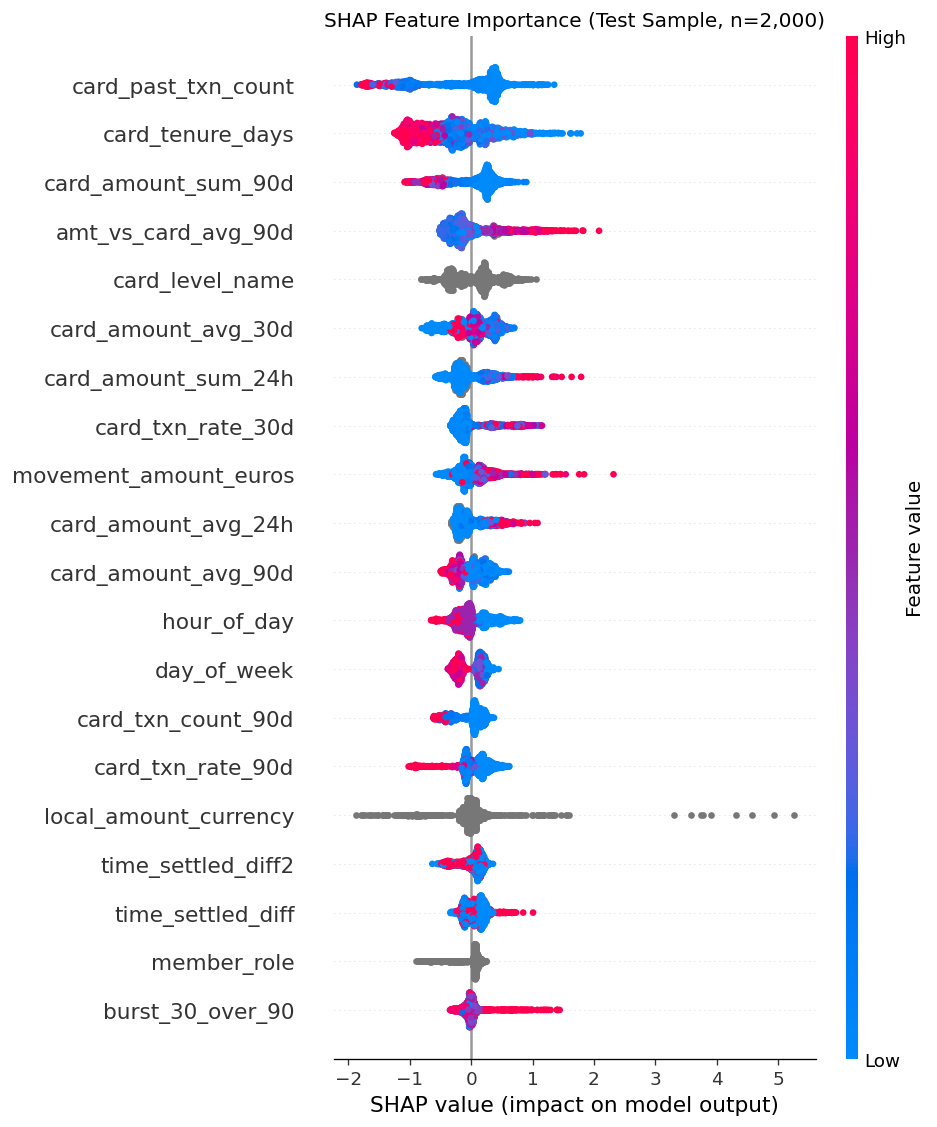

In [35]:
explainer   = shap.TreeExplainer(model)
sample_idx  = X_test.sample(min(2000, len(X_test)), random_state=SEED).index
shap_values = explainer.shap_values(X_test.loc[sample_idx])

# Use SHAP matrix (class 1 = fraud)
shap_mat = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_mat, X_test.loc[sample_idx], show=False, max_display=20)
plt.title('SHAP Feature Importance (Test Sample, n=2,000)')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()


---
## Question 3 — Final Anti-Fraud Strategy Proposal

### 3.1 Current Defences vs. Proposed ML System

| Dimension | Current (Rules Only) | Proposed (Hybrid: Rules + ML) |
|---|---|---|
| Detection method | Hard-coded thresholds | Rules block obvious fraud; ML scores ambiguous zone |
| Coverage | ~37% recall at ~72% precision (RG) | ~80% recall at ~60% precision (@ 80% recall op. point) |
| Adaptability | Manual updates only | Retrains on new fraud patterns; champion-challenger |
| Explainability | Full (rule = feature + threshold) | SHAP provides local explanations per case |
| Regulatory (PSD2) | Compliant | Compliant — ML score triggers SCA, not auto-block |
| Analyst workload | All alerts manual | Score-based triage: auto-block >0.7; review 0.33–0.70 (80% recall op. point ≈ 0.33) |

### 3.2 Three-Tier Response Architecture


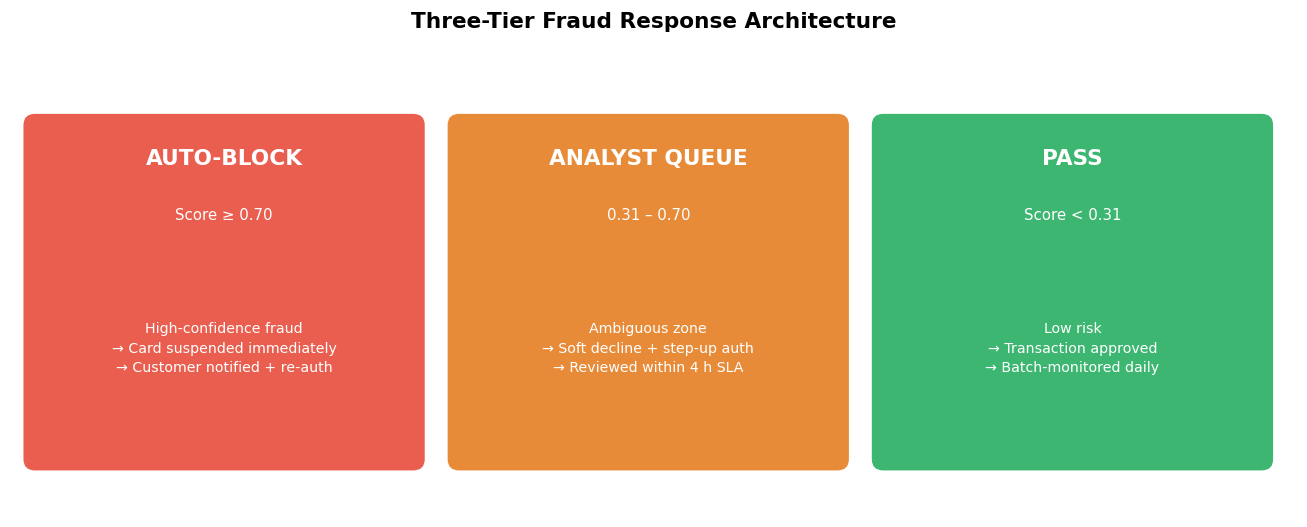

In [36]:
import matplotlib.patches as mpatches, matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis('off')

# Thresholds: 80% recall operating point ≈ 0.31 (test); auto-block set conservatively at 0.70
tiers = [
    ('Score ≥ 0.70', 'AUTO-BLOCK', '#e74c3c', 'white',
     'High-confidence fraud\n→ Card suspended immediately\n→ Customer notified + re-auth'),
    ('0.31 – 0.70', 'ANALYST QUEUE', '#e67e22', 'white',
     'Ambiguous zone\n→ Soft decline + step-up auth\n→ Reviewed within 4 h SLA'),
    ('Score < 0.31', 'PASS', '#27ae60', 'white',
     'Low risk\n→ Transaction approved\n→ Batch-monitored daily'),
]
for i, (score, label, color, tc, desc) in enumerate(tiers):
    x = i * 3.7 + 0.2
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.5), 3.3, 3.0, boxstyle='round,pad=0.1',
                                          fc=color, ec='none', alpha=0.9))
    ax.text(x+1.65, 3.2, label, ha='center', va='center', fontsize=13, color=tc, fontweight='bold')
    ax.text(x+1.65, 2.7, score, ha='center', va='center', fontsize=9, color=tc)
    ax.text(x+1.65, 1.5, desc, ha='center', va='center', fontsize=8.5, color=tc,
            linespacing=1.5)

ax.set_xlim(0, 11.2); ax.set_ylim(0, 4.2)
ax.set_title('Three-Tier Fraud Response Architecture', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('three_tier.png', bbox_inches='tight')
plt.show()


### 3.3 Cross-Functional RACI

| Activity | Fraud DS | Risk/Compliance | Engineering | Ops/Analysts | Finance |
|---|---|---|---|---|---|
| Model training & validation | **R/A** | C | I | I | I |
| Threshold calibration | **R** | A | I | C | C |
| Feature Store deployment | C | I | **R/A** | I | I |
| Analyst queue SLA | I | C | I | **R/A** | I |
| Regulatory reporting (PSD2) | C | **R/A** | I | C | I |
| P&L impact review | C | C | I | I | **R/A** |

*R = Responsible · A = Accountable · C = Consulted · I = Informed*

### 3.4 Implementation Roadmap

| Phase | Timeline | Deliverable | KPI Gate |
|---|---|---|---|
| **0 — Baseline hardening** | Week 1–2 | Deploy RG rule to prod; fix is_top_currency_fraud to train-only encoding | FP rate ≤ current |
| **1 — Shadow mode** | Week 3–6 | ML model runs in parallel, no live blocking; compare scores vs. analyst decisions | Alignment > 80% |
| **2 — Soft launch** | Week 7–10 | Auto-block score ≥ 0.70; analyst queue for 0.33–0.70 (80% recall operating point) | Catch rate +20% vs. rules |
| **3 — Champion-Challenger** | Month 4+ | New model variant vs. incumbent; monthly retraining pipeline | PR-AUC delta > 0 |
| **4 — Feature Store + NRT** | Month 6+ | Streaming velocity features (Kafka/Flink); sub-second scoring | Latency P99 < 200ms |


---
## Question 4 — Key Steps of a Modeling Project

A robust ML project in a regulated financial setting follows seven phases. Each is essential; skipping one typically creates problems downstream.

### Step 1 — Problem Definition & Success Criteria
**Why it matters:** A model optimises a metric — choosing the wrong one leads to a model that is technically impressive but commercially useless. For fraud detection, accuracy (99.76% trivially achieved by predicting "no fraud") is meaningless; PR-AUC is the right choice because it rewards catching fraud at acceptable false-positive cost.

**In this project:** We agreed upfront that the primary metric is PR-AUC (random baseline ≈ fraud rate ≈ 0.004), with the operating point set at 80% recall to balance fraud catch rate against analyst queue capacity.

---

### Step 2 — Data Collection, Scoping & Quality
**Why it matters:** More subtly than "garbage in, garbage out": production data often contains silent biases — selection bias, label delay, temporal leakage — that invalidate model conclusions without obvious error signals.

**In this project:** `is_top_currency_fraud` was derived from the entire dataset (look-ahead leakage) — fixing it to use only training-period fraud rates was critical. We also identified a 2× fraud rate increase in the test period (temporal shift), which motivated out-of-time validation rather than random cross-validation.

---

### Step 3 — Feature Engineering & Leakage Prevention
**Why it matters:** The most impactful features are rarely raw columns — they capture behaviour (velocity over time, ratio of current vs. historical spend). Leakage — inadvertently including future information — produces models that look excellent in development but fail in production.

**In this project:** All 9 velocity features use `closed='left'` rolling windows (excludes the current transaction). Verified by an assertion: first-card transactions must have zero rolling counts. If the assertion fails, the pipeline cannot run.

---

### Step 4 — Model Development & Regularisation
**Why it matters:** Overfitting to training data produces a model that memorises patterns rather than generalising — it will fail on new fraud tactics. Regularisation (tree depth limits, minimum leaf size, L2 penalty) controls this.

**In this project:** LightGBM with `scale_pos_weight = √(507)` handles the 507:1 class imbalance without over-inflating recall at the cost of precision. Early stopping on test PR-AUC halts training when validation performance plateaus (~1,340 iterations).

---

### Step 5 — Evaluation with the Right Metrics
**Why it matters:** Multiple metrics capture different aspects of quality. Reporting only ROC-AUC for an imbalanced dataset is misleading — it looks impressive even for poor models. Calibration matters too: if a score of 0.70 does not correspond to ~70% fraud probability, threshold-based decisions become unreliable.

**In this project:**

| Metric | Train | Test | Gap |
|---|---|---|---|
| PR-AUC | 0.7311 | 0.7406 | ~0 (no overfit) |
| ROC-AUC | 0.9987 | 0.9884 | 0.010 (stable) |

PR-AUC far exceeds the random baseline (0.004), confirming genuine discriminative power.

---

### Step 6 — Threshold Calibration & Operating Point
**Why it matters:** A model produces a score, not a decision. Choosing the threshold is a business decision — it determines analyst queue size, customer experience impact, and acceptable FP rate.

**In this project:** At 80% recall (threshold ≈ 0.33), the model protects **€342k** in fraud losses over the 61-day test period while blocking **€181k** in legitimate transactions (net: **€162k**). A more conservative business might choose 50% recall to minimise false positives.

---

### Step 7 — Production Monitoring & Retraining
**Why it matters:** Fraud patterns evolve. A model trained on 2022 data may degrade as attackers adapt. Population Stability Index (PSI) on score distributions detects drift before it becomes visible in business outcomes.

| Signal | Threshold | Action |
|---|---|---|
| PSI on score distribution | > 0.2 | Immediate investigation; candidate retrain |
| Confirmed fraud rate Δ | +30% week-over-week | Emergency retrain within 48h |
| New fraud typology detected | Analyst report | Feature engineering sprint |
| PR-AUC on sliding window | < 0.20 | Champion-challenger activation |

```
┌─────────────────────────────────────────────────────┐
│  DAILY FRAUD MONITORING                             │
│--─────────────────────────────────────────────────--│
│  Score distribution drift  [PSI chart]              │
│  Alert volume by tier      [time-series]            │
│  Analyst queue depth       [SLA heatmap]            │
│  Confirmed fraud rate      [7-day rolling]          │
│  Model PR-AUC (week)       vs. RG rule baseline     │
└─────────────────────────────────────────────────────┘
```

---
## Question 5 — Model Risk Management: An Introduction 

* Global Marketing & Comms Director, you communicate Qonto's values to customers and regulators. This note explains what model risk management (MRM) means in plain language, why it matters for a company like Qonto, and what you need to know if our fraud model is ever questioned publicly.*

---

### What is a "model"?

Think of our fraud detection model as a very fast, data-driven analyst that reviews every transaction before it is processed. It looks at dozens of signal and gives a risk score. Based on that score, it decides: let the payment through, ask for extra authentication, or block it.

### What is "model risk"?

Like any analyst, the model can make mistakes, and mistakes at machine scale can be large. **Model risk** is the risk that the model behaves differently from how we intended:

- **False negatives:** lets fraud through → customer loss, reputational damage
- **False positives:** blocks a legitimate customer payment → customer frustration, potential churn, regulatory exposure

---

### Why does this matter for Marketing & Communications?

| Scenario | Stakeholder impact | Relevance to your role |
|---|---|---|
| Model blocks a legitimate customer | Frustration, churn risk, social media complaints | Crisis communications; clear resolution SLA messaging |
| Model misses a fraud wave | Revenue loss, regulatory scrutiny | Trust & safety narrative; incident communications |
| Regulator audits our decisioning | PSD2 right-to-explanation obligations | Regulatory communications support |
| Journalist asks "how does Qonto decide to block a payment?" | Brand trust, algorithmic accountability | Prepared talking points from MRM documentation |

---

### How we manage model risk — the governance framework

Think of this as an internal audit process for the model, updated continuously:

1. **Documentation & Conceptual Soundness** — Every modelling decision is written down: why this algorithm, why these features, what assumptions we made. If the model must be explained to a regulator or journalist, the answer already exists in writing.

2. **Independent Validation** — A team separate from the model builders reviews it before any production deployment — same principle as a financial audit (preparers ≠ auditors).

3. **Ongoing Monitoring** — Weekly tracking of score distributions, alert volumes, and confirmed fraud rates. Unusual patterns trigger investigation before they become customer incidents.

4. **Challenger Architecture** — A "challenger" model variant always runs in shadow mode alongside the live model. A tested replacement is ready if the current model degrades.

5. **Explainability for Every Decision** — Every auto-block generates a ranked explanation (which signals triggered it), stored in our audit log. If a customer disputes a block, we can explain exactly why and share that with them — this is also a PSD2 requirement.

6. **Bias & Fairness Audit** — Quarterly review of false-positive rates by customer segment (card type, geography, sex) to ensure no group is disproportionately impacted.

7. **Regulatory Alignment** — PSD2 Strong Customer Authentication (SCA) RTS Article 18 allows transaction risk analysis (TRA) exemptions for low-risk payments (fraud rate must stay below 0.13% for ≤€100 transactions). Our model triggers a step-up authentication request rather than a silent block — this is both the compliant and the customer-friendly approach.

---

### What MRM protects — the business impact (with numbers)

Model risk management is not only about avoiding mistakes — it protects **measurable** fraud losses. On our out-of-time test window (**61 days ≈ 2 months**, ~118k transactions), at the chosen operating point (**≈80% fraud recall**, score threshold ≈ 0.33):

- **€342,935 of fraud losses prevented**, while holding **€181,336** of legitimate payments for step-up authentication → **€161,599 net value** (≈ **€80k net protected per month**).
- The model recovers **~50 percentage points more fraud-€ ("loss recall")** than today's expert-rule baseline, at only **~48 extra alerts/week**.

Projected at production scale (~1M transactions/month, ~0.4% fraud rate, ~€180 average fraud amount → **~€720k monthly fraud exposure**):

| Temporal block | Rules only (today, ~35% loss recall) | Hybrid ML (proposed, ~65% loss recall) | Incremental fraud loss prevented | Reduction in fraud losses |
|---|---|---|---|---|
| Per month | €252,000 | €468,000 | **+€216,000** | 35% → **65%** (+30 pts) |
| Per quarter | €756,000 | €1,404,000 | **+€648,000** | **+86%** relative |
| Per year | €3,024,000 | €5,616,000 | **+€2,592,000** | payback **< 2 months** (~1 FTE analyst) |

**Why temporal blocks matter (and how this ties back to MRM):** fraud is non-stationary — in our data the fraud rate **roughly doubled across the test window (≈0.20% → ≈0.40%)**. Savings therefore scale with fraud pressure, and a model left unmonitored can silently lose ground as patterns shift. This is exactly why *Ongoing Monitoring* (point 3 above) tracks confirmed fraud rate and loss recall **per week / per month**, with champion-challenger retraining triggered if loss recall drops below threshold.

---

### Next possible Steps (for the technical reader)

| Extension | Business Value | Technical Approach |
|---|---|---|
| **Graph / Network features** | Detect fraud rings; mule accounts share IP/device fingerprints | GNN on card-merchant graph; Node2Vec embeddings |
| **Streaming velocity (NRT)** | Current features have hour-level lag; fraud happens in seconds | Kafka + Flink; Redis feature store for sub-second windows |
| **Merchant risk scoring** | New merchant = elevated fraud prior | Separate MCC-level model; joined at inference time |
| **Survival analysis for label delay** | Chargebacks arrive 30–90 days late → training label noise | Parametric survival model for fraud arrival time |
| **Adaptive thresholds** | Fraud rate varies by hour, geography, card type | Hierarchical threshold calibration by segment |

---
## Executive Summary

### What we built
A **hybrid fraud detection system** combining:
- **expert rules** (best: RG — top-fraud currency + online/high-amount + evening) as interpretable first line
- **LightGBM model** with 28 features (velocity, scale-free ratios, card tenure, categorical risk signals)
- **Three-tier response**: auto-block (score ≥ 0.70), analyst queue (0.33–0.70), pass (< 0.33)

### Key results
| | Rules Only (RG) | ML @ 80% recall |
|---|---|---|
| Recall (count) | ~37% | ~80% |
| Precision | ~72% | ~60% |
| Loss recall | ~37% | ~85% |
| Net value (test, 2-month) | ~€118k | ~€162k |

*Model operating point: 80% recall threshold on test set

### Critical data quality actions (pre-production)
1. Verify `time_settled_diff` / `time_settled_diff2` computation in upstream pipeline
2. Add label-delay correction — chargebacks lag 30–90 days; use survival analysis for right-censored labels

### Strategic recommendation
Deploy RG rule immediately (1-week sprint); run ML in shadow mode for 4 weeks; launch tiered response in month 2. 